# Imports

In [52]:
%load_ext autoreload
%autoreload 2

import logging
import numpy as np
import matplotlib.pyplot as plt

import msml610_utils as ut

ut.config_notebook()

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


INFO:msml610_utils:Setting notebook style
INFO:msml610_utils:Notebook signature
INFO:msml610_utils:numpy version=1.26.4
INFO:msml610_utils:pymc version=5.18.2
INFO:msml610_utils:matplotlib version=3.10.3
INFO:msml610_utils:arviz version=0.21.0
INFO:msml610_utils:preliz version=0.19.0


Python 3.12.3
Linux 7d77d2247121 6.12.67-linuxkit #1 SMP Sun Jan 25 02:26:28 UTC 2026 aarch64 aarch64 aarch64 GNU/Linux


In [5]:
import helpers.hio as hio
import L09_05_03_multivariate_kalman_filter_utils as time_ut

dst_dir = "figures"
hio.create_dir(dst_dir, incremental=True)
# cp msml610/tutorials/figures/*.png msml610/lectures_source/figures

In [26]:
!sudo /bin/bash -c "(source /venv/bin/activate; pip install --quiet filterpy)"

import filterpy

# Cell 1: Multi-variate Gaussians

- A multivariate Gaussian is a normal distribution on multiple dimensions
    - The dimensions don't need to be necessarily spatial dimensions
    - E.g., position, velocity, acceleration in 3 dimensions
    - E.g., milk production and feed rate at a dairy

- The components of a Gaussian are correlated
  - E.g., height and weight of people are (positively) correlated
  - E.g., outdoor temperature and home heating bills are (negatively) correlated
  - E.g., the weight of my dog and the price of coffee are uncorrelated

- Correlation allows prediction
  - E.g., height and weight are correlated. If you are much taller than me, I can predict that you weigh more than me
  - Noise in the measurements, uncertainty in the knowledge of the system, intrinsic stochasticity make correlations (and predictions) imperfect

- Assuming linear correlation, the covariance between two vars is defined as
  $$cov(X, Y) = E[(X - \mu_X)(Y - \mu_Y)]$$

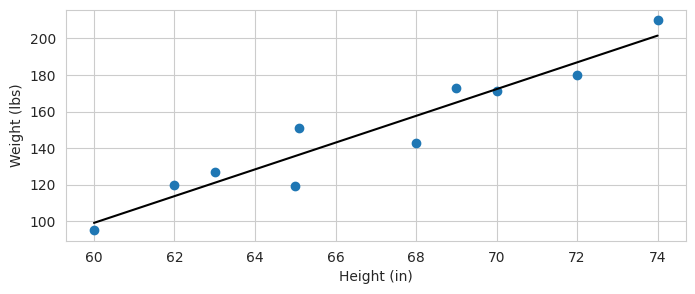

cov=
 [[  20.58322222  150.77888889]
 [ 150.77888889 1213.65555556]]


In [14]:
height = [60, 62, 63, 65, 65.1, 68, 69, 70, 72, 74]
weight = [95, 120, 127, 119, 151, 143, 173, 171, 180, 210]
time_ut.plot_correlated_data(height, weight, xlabel='Height (in)', ylabel='Weight (lbs)', equal=False)
print("cov=\n", np.cov(height, weight))

In [18]:
from filterpy.stats import gaussian, multivariate_gaussian

x = [2.5, 7.3]
mu = [2.0, 7.0]
P = [[8., 0.], 
     [0., 3.]]

multivariate_gaussian(x, mu, P)

0.031507521572225645

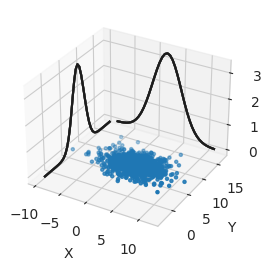

In [19]:
time_ut.plot_3d_sampled_covariance(mu, P)

In [23]:
time_ut.cell_1_1_plot_covariance_matrix()

## Using Correlations to Improve Estimates

- Given an aircraft that we need to locate on a 2D map, ignoring the altitude
- We are tracking an aircraft with two radars
  - Each radar provides the position as two coordinates, such as the "range"
    (distance) and the "bearing" (angle) to a target

- The areas on the X-Y diagrams represent where the plane is likely to be

- One radar measurement (let's assume it's the prior) is equally distributed
  across the two axes (yellow)
- The other radar measurement (let's assume it's the evidence) instead is
  inaccurate along the range but precise along the bearing estimates (green)
- The posterior is given by the multiplication of the two Gaussians (blue)
  - The uncertainty of the posterior is the smaller than the two other measurements

[[1.23099851 1.13263785]
 [1.13263785 1.23099851]]


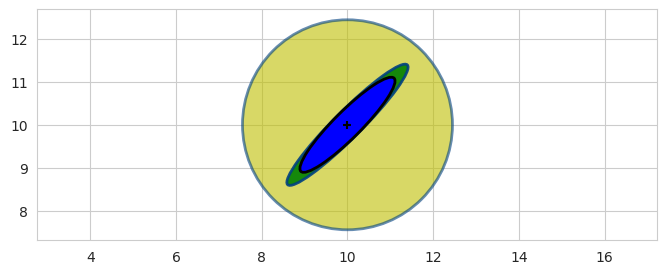

In [32]:
# Prior.
P0 = [[6, 0], [0, 6]]
filterpy.stats.plot_covariance_ellipse((10, 10), P0, fc='y', alpha=0.6)

# Evidence.
P1 = [[2, 1.9], [1.9, 2]]
filterpy.stats.plot_covariance_ellipse((10, 10), P1, fc='g', alpha=0.9)

# Posterior.
P2 = filterpy.stats.multivariate_multiply((10, 10), P0, (10, 10), P1)[1]
print(P2)
filterpy.stats.plot_covariance_ellipse((10, 10), P2, ec='k', fc='b')

- If the two measurements are like below, the resulting measurement is much smaller
  - We are "triangulating" the aircraft
  - This is optimal when the radars are orthogonal

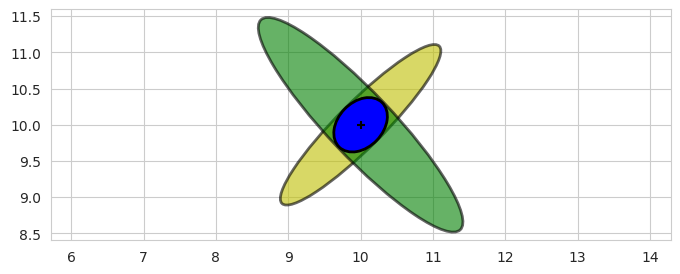

In [34]:
P3 = [[2, -1.9], [-1.9, 2.2]]
filterpy.stats.plot_covariance_ellipse((10, 10), P2, ec='k', fc='y', alpha=0.6)
filterpy.stats.plot_covariance_ellipse((10, 10), P3, ec='k', fc='g', alpha=0.6)

P4 = filterpy.stats.multivariate_multiply((10, 10), P2, (10, 10), P3)[1]
filterpy.stats.plot_covariance_ellipse((10, 10), P4, ec='k', fc='b')

# Cell 1: Sum and Product of Bidimensional Gaussians

## Sum of Two 2D Gaussians

- If $X \sim N(0, \Sigma_1)$ and $Y \sim N(0, \Sigma_2)$ are independent,
  then $X + Y \sim N(0, \Sigma_1 + \Sigma_2)$: the covariances add
    - Yellow: G1
    - Green: G2
    - Blue: G1 + G2
- The sum is always larger (less certain) than either factor

In [43]:
time_ut.cell_1_2_plot_sum_of_gaussians()

## Product of Two 2D Gaussians

- The product of two Gaussian PDFs is also a Gaussian (up to normalization)
- Given $G1 \sim N(0, \Sigma_1)$ and $G2 \sim N(0, \Sigma_2)$:
  $\Sigma^{-1} = \Sigma_1^{-1} + \Sigma_2^{-1}$
    - Yellow: G1
    - Green: G2
    - Blue: G1 * G2
- The product is always smaller (more certain) than either factor

In [44]:
time_ut.cell_1_3_plot_product_of_gaussians()

# Tracking a Dog with Hidden Variables

- We go back to tracking a dog on a 1-d track and use hidden variables to
  improve our estimates
  - The underlying ideas are the same as the previous chapters: we are just
    multiplying and adding Gaussians

- The dog moves approximately 1 meter per step
  - At each step, the velocity varies according to the process variance
    `process_var`
  - After updating the position, a measurement is computed with an assumed
    sensor variance `z_var`
  - Time is discrete

- We start by writing a simulation for the dog
  - The simulation runs for `count` steps

In [50]:
z_var = 1.0
process_var = 0.1
count = 50
xs, zs = time_ut.compute_dog_data(z_var, process_var, count=count)
print("xs=", xs)
print("zs=", zs)

xs= [ 0.65477387  1.87472222  2.78176171  3.30176789  4.58333177  5.74165617
  6.74388974  7.96487869  9.12046871  9.43952189 10.28810019 11.50739747
 12.84257879 14.05874239 15.44199273 16.32521704 16.76352214 17.43800629
 17.95659405 18.75760349 19.58816819 20.23509216 21.18579283 22.23639503
 23.58974756 24.47597873 25.34522957 26.04046223 27.14917751 28.15954883
 29.08668972 30.36819518 30.78437932 31.31113521 32.28474981 32.99323214
 34.05877583 34.83054237 35.65766695 37.18685897 37.77589529 39.03248141
 40.29140164 40.9364218  42.25823461 43.43262673 44.55617562 45.88736656
 46.81482684 47.33064813]
zs= [ 0.26767417  2.72382433  2.71016246  2.94473869  5.15853678  5.79142986
  6.0835686   8.38585163  8.59443386 10.5366746   9.42532442 11.11538483
 13.45958474 12.69278668 15.70324326 16.46860551 17.17217495 16.085336
 19.06928242 20.2913312  17.88081023 21.47090378 20.63750553 22.73817777
 25.03824679 23.14993104 25.60551007 25.08331132 27.10052516 27.40105349
 28.16245658 31.403

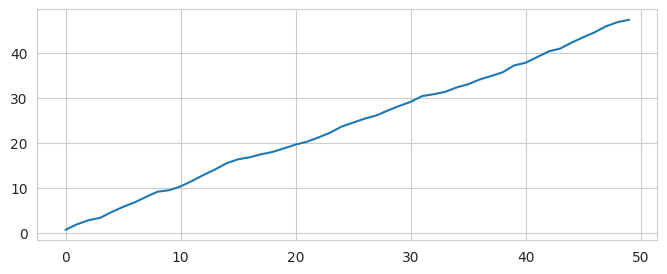

In [54]:
plt.figure(figsize=(8, 3))
plt.plot(xs, label="True position (xs)");

* Tracking Dog: Predict Step
- At each step, the position is described with a Gaussian distribution
  $Normal(\mu, \sigma^2)$

- The position is part of the system's state, along with the velocity
  - The position is "observed" by a sensor
  - The velocity is a "hidden" variable
  - You could use more variables (E.g., acceleration, jerk, etc.)

## Design State Covariance
- Initialize variances to reasonable values
  - E.g., $\sigma_{position} = 500m$ due to uncertainty about initial position
  - Top speed for a dog is 21m/s, so set $3 \sigma_{velocity} = 21$
  - Assume covariances to be zero due to unknown initial correlation between
    position and velocity
  - $P$ is diagonal

## Design System Model
- Describe mathematically the behavior of the system
  $$
  x_{t+1} = x_t + v \Delta t
  $$
- No model to predict how dog velocity changes over time
  - Assume it remains constant
    $$
    \dot{x}_{t+1} = \dot{x}_t
    $$
  - This is not correct, but if velocity doesn't change much, the filter will
    perform well
- Put the model in matrix form $\vx_{t+1} = \mF \vx_t$

## Predicting the System

- If we predict the system without measurements:
  - The state follows the system model
  - The state uncertainty grows
    - This is true even without system error (noise)


## Design System Noise

- Consider a car driving on a road with cruise control on
- It should travel at constant speed:

  $$
  x_t = \dot{x}_{t-1} \Delta t + x_{t-1}
  $$

- In reality, it is affected by unknown factors:
  - The cruise control is not perfect
  - Wind, hills, potholes affect the car
  - Passengers roll down windows, changing the drag profile of the car

- Model this as:

  $$
  \dot{x}_t = \dot{x}_{t-1} + w
  $$

- Model all of this with a covariance matrix $\mQ = \EE[\vw \cdot \vw^T]$:
  - Assume the noise is iid, has zero mean, and is independent from the system
  - For these reasons, you don't have to change the position, only the velocity

## Design the Control Function
- Incorporate control inputs to predict state based on this information
  $$
  \Delta \overline{\vx} = \mB \vu
  $$
- E.g., in the case of the car
  - Steering
  - Acceleration
- E.g., in the case of the dog, control inputs can be
  - The voice of its master
  - Seeing a squirrel

## Update Step

* Tracking Dog: Design the Measurement Function
- Kalman filter computes the update step in the measurement space

- If the measurement is in the same units as the state, the residual is simple
  to compute:

  $$
  \text{residual = measured position - predicted position}
  $$

- E.g., assume we are tracking the position of the dog using a sensor that
  outputs a voltage
  - We cannot compute the residual as:
    $$
    \text{measure voltage - predicted position}
    $$
  - We need to convert the position into voltage

- The Kalman space allows to have a measurement matrix $\mH$ to convert the
  state into a measurement

  $$
  \vy = \vz - \mH \overline{\vx}
  $$

* Why Working in Measurement and Not in State Space?
- The problem is that it is possible to convert state into measurement, but not
  vice versa because of the hidden variables
  - E.g., transform position (discarding velocity) into voltage
  - If the sensor doesn't read velocity how do we estimate the measured velocity

* Tracking Dog: Design the Measurement
- Typically $\vz$ is easy since it just contains the measurements from the
  sensor

- The measurement noise matrix $\mR$ can be difficult to estimate
  - Noise can be not Gaussian
  - There can be a bias in the sensor
  - The error can be not symmetrical (e.g., temperature sensor is less precise
    as the temperature increases)
